***Time Series Analysis of Rossman store Dataset***

In this section, all different methodology to analyze time series records will be discussed. We will be using statsmodels python module for data analysis efficiently.

References: 

1. Youtube: https://www.youtube.com/watch?v=DeORzP0go5I&list=PLvcbYUQ5t0UHOLnBzl46_Q6QKtFgfMGc3&index=2

2. Textbook: https://otexts.com/fpp3/determining-what-to-forecast.html

***Statsmodels:***

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

***Load the data***

In [52]:
data_f = pd.read_csv("/Users/adityatripathi/Desktop/Court_Documents/Projects/Time_Series_Rossman_Retail/rossmann_dataset.csv"
                    , index_col='Date'
                    , parse_dates=True)

/var/folders/x2/klypyxc135nfqxlbmhpj3zq40000gn/T/ipykernel_54731/2517772817.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  data_f = pd.read_csv("/Users/adityatripathi/Desktop/Court_Documents/Projects/Time_Series_Rossman_Retail/rossmann_dataset.csv"


In [53]:
data_f.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
Date,,,,,,,,
2015-07-31,1,5,5263,555,1,1,0,1
2015-07-31,2,5,6064,625,1,1,0,1
2015-07-31,3,5,8314,821,1,1,0,1
2015-07-31,4,5,13995,1498,1,1,0,1
2015-07-31,5,5,4822,559,1,1,0,1


In [54]:
data_f.shape

(1017209, 8)

In [55]:
#Let's see what we can do here

***Plot***

In [60]:
#plot the sales data of store 1
data_f1.shape

(942, 8)

In [61]:
#Sorting the data which is our index here.
data_f.sort_index(inplace = True)

In [62]:
data_f.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
Date,,,,,,,,
2013-01-01,1115,2,0,0,0,0,a,1
2013-01-01,379,2,0,0,0,0,a,1
2013-01-01,378,2,0,0,0,0,a,1
2013-01-01,377,2,0,0,0,0,a,1
2013-01-01,376,2,0,0,0,0,a,1


In [63]:
#filter our first store and look for what is it saying
data_f1 = data_f.loc[data_f['Store'] == 1]

In [64]:
data_f1.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
Date,,,,,,,,
2013-01-01,1,2,0,0,0,0,a,1
2013-01-02,1,3,5530,668,1,0,0,1
2013-01-03,1,4,4327,578,1,0,0,1
2013-01-04,1,5,4486,619,1,0,0,1
2013-01-05,1,6,4997,635,1,0,0,1


In [65]:
#This does not make any sense cause sales is purely on day bases
data_f2 = data_f1.groupby(by='Date').agg({'Sales':sum})
data_f2.sort_index(inplace=True)

In [66]:
#If you observe the sales on some days is 0 cause it is holiday presumably.
data_f2

,Sales
Date,
2013-01-01,0
2013-01-02,5530
2013-01-03,4327
2013-01-04,4486
2013-01-05,4997
...,...
2015-07-27,6102
2015-07-28,5011
2015-07-29,4782


In [67]:
#Resampling the data on Monthly level
data_f3 = data_f2.resample('MS').sum()

In [68]:
#This make sense the average monthly sales is around 12k-14k.
data_f3.head(4)

,Sales
Date,
2013-01-01,128431
2013-02-01,125271
2013-03-01,145169
2013-04-01,118009


In [69]:
data_f3.shape

(31, 1)

In [70]:
#Now let's plot Daily sales of store1

[Text(0, 0.5, 'Total Daily Sales of Store1')]

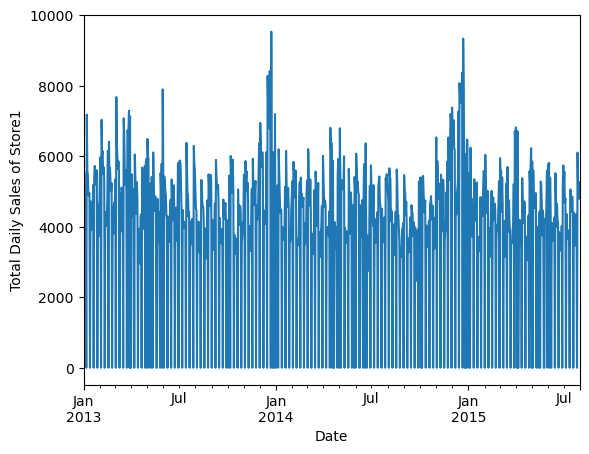

In [71]:
#Plotting our sales for store 1 to see the real meaning
#We observed sudden drops, spikes and also a middle flat layer 
#Sudden drops are happening, spikes happen at Jan of every year(2014, 2015) and in general the trend in middle graph is flat
ax = data_f1['Sales'].plot()
ax.autoscale(axis='x', tight=True)
ax.set(ylabel='Total Daily Sales of Store1')

In [72]:
#Let's look what are these crashes at zero
#This proves that there was not a single day when the sales was 
data_f1.loc[(data_f1['Open'] == 1) & (data_f1['Sales'] == 0)]

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
Date,,,,,,,,


In [73]:
##Now let's plot weekly sales of store1

In [74]:
#So inorder to figure out the the zero crashes, we need to look into weekly totals.
Weekly_Sales = data_f1.resample('W').sum()

[Text(0, 0.5, 'Total Weekly Sales of Store1')]

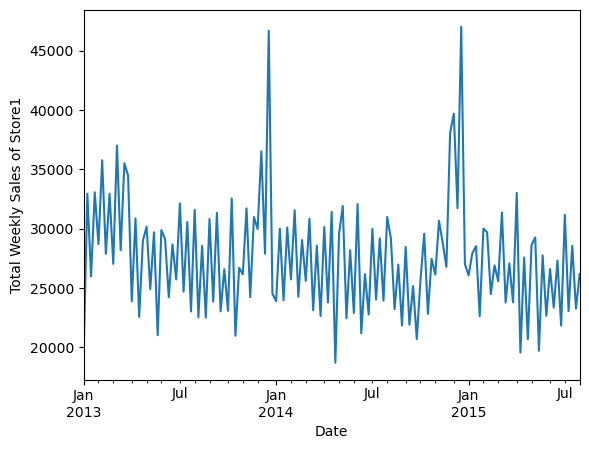

In [75]:
#Look how the zero crashes are gone.
#Just think we would have feeded the previous data to our algo it would have crashed instantly.
#Just by taking weekly sales the lowest the store ever drop is around 20,000. Ignoring those zero crashes in daily sales graph.
ay = Weekly_Sales['Sales'].plot()
ay.autoscale(axis='x', tight=True)
ay.set(ylabel='Total Weekly Sales of Store1')

[Text(0, 0.5, 'Total Monthly Sales of Store1')]

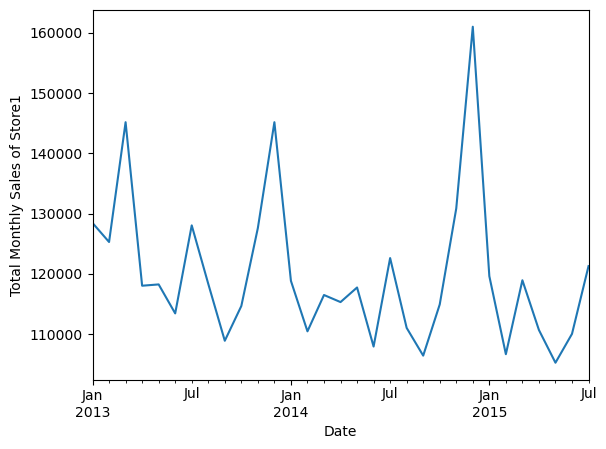

In [76]:
#Now let's plot monthly sales of store1
az = data_f3['Sales'].plot()
az.autoscale(axis='x', tight=True)
az.set(ylabel='Total Monthly Sales of Store1')

***Recognized daily sales data as noisy for baseline analysis. Selected weekly aggregation as the baseline timeline. Did see monthly sales too but for now we will proceed with weekly analysis***

Time series forecasting is always a balancing act between noise and signal.

Daily was too noisy: (The Sundays crashed to zero, hiding the trend).

Monthly is too smooth: If you smash 30 days of sales into one giant monthly number, you completely blind the algorithm to how the business actually runs. You hide paydays, mid-month slumps, and week-long promotions.

Weekly is "just right": Retailers operate in weekly cycles. Promotions run Monday-Sunday. Store managers schedule staff by the week. Weekly gives us a perfectly smooth line that still captures the fast-paced heartbeat of a retail store.

In [77]:
import seasonal

In [78]:
def seasonal_period_udf(counts):
    seasons, trend = seasonal.fit_seasons(counts, trend='spline')
    if(seasons is not None): return len(seasons)
    else: return -1

In [79]:
seasonal_period_udf(Weekly_Sales['Sales'].values)

52

***Trend Calculation***

We can use functionalities of statsmodels to get the trend value from a time series data.

Here we can use statsmodels.tsa.filters.hp_filter.hpfilter(X, lamb=1600) the Hodrick Prescott filter. It filter our time series yt into a trend component rt and cyclical component ct.

In [80]:
from statsmodels.tsa.filters.hp_filter import hpfilter

#get the values
sales_cycle, sales_trend = hpfilter(Weekly_Sales['Sales'], lamb=1200)

In [81]:
sales_cycle

Date
2013-01-06   -9823.482738
2013-01-13    3631.056121
2013-01-20   -3492.218785
2013-01-27    3464.852900
2013-02-03   -1027.658286
                 ...     
2015-07-05    5886.405698
2015-07-12   -2249.792721
2015-07-19    3253.511157
2015-07-26   -2041.943133
2015-08-02     875.872682
Freq: W-SUN, Name: Sales_cycle, Length: 135, dtype: float64

In [82]:
sales_trend

Date
2013-01-06    29163.482738
2013-01-13    29320.943879
2013-01-20    29470.218785
2013-01-27    29606.147100
2013-02-03    29720.658286
                  ...     
2015-07-05    25288.594302
2015-07-12    25290.792721
2015-07-19    25294.488843
2015-07-26    25297.943133
2015-08-02    25302.127318
Freq: W-SUN, Name: Sales_trend, Length: 135, dtype: float64

Trend seems monotonically increasing every year weely. Append the trend value in additional columns

In [83]:
Weekly_Sales['Trend'] = sales_trend

In [84]:
Weekly_Sales.head(4)

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,Trend
Date,,,,,,,,
2013-01-06,6,27,19340,2500,4,0,6,29163.482738
2013-01-13,7,28,32952,3918,6,5,5,29320.943879
2013-01-20,7,28,25978,3417,6,0,0,29470.218785
2013-01-27,7,28,33071,3862,6,5,0,29606.147100


***Plot the trend***

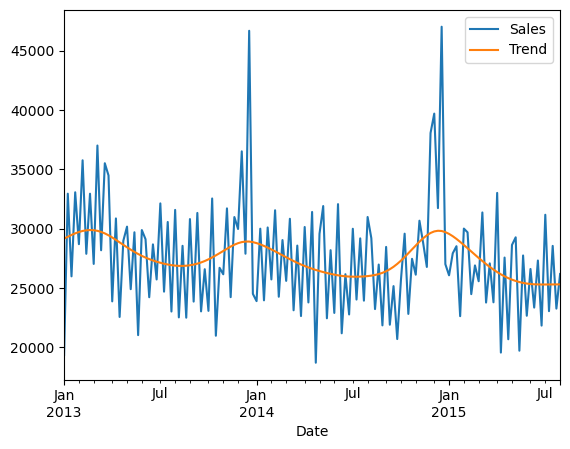

In [85]:
Weekly_Sales[['Sales', 'Trend']].plot().autoscale(axis='x', 
                                                  
                                                  tight=True)

***Plot the cyclic values***

In [86]:
Weekly_Sales['Sales_Cyclic'] = sales_cycle

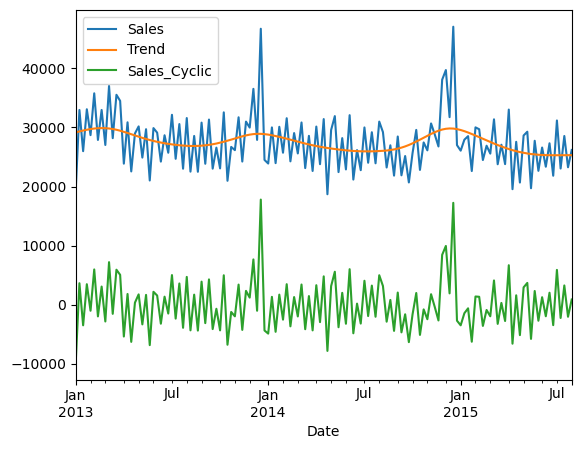

In [87]:
Weekly_Sales[['Sales', 'Trend', 'Sales_Cyclic']].plot().autoscale(axis='x', 
                                                                  
                                                                  tight=True)

From the graph it is evident that the original series is the summation of trend component and the cyclic component.

In [88]:
#Now we are going to use famous Python Library called statsmodels to physically rip this sinle blue line apart
#Into three separate graphs so we can see the pure trend without holiday spikes getting in the way.
from statsmodels.tsa.seasonal import seasonal_decompose

In [89]:
result = seasonal_decompose(Weekly_Sales['Sales'], model = 'additive')

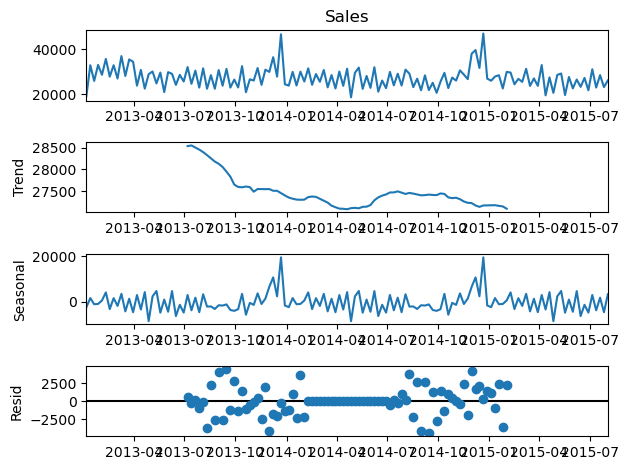

In [90]:
result.plot();

***Since you have the core logic of decomposition locked in, it is time to move to step 3: The Need for Proof(Autocorrelation)***

Right now, we know the seasonality exists because our human eyes can see it in that third panel. But an algorithm doesn't have eyes.If we want to build a ML model to predict the future, we have to mathematically prove to the computer exactly how. much the past influences the present.

This is exactly what the ritvikmath video you watched was teaching you we are going to build an ACF(Autocorrelation Function) plot. 


It will take your current week of sales and compare it to 1 week ago, then 2 weeks ago, 3 weeks ago, all the way back, measuring the mathematical correlation at each step. 

In [91]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf,pacf

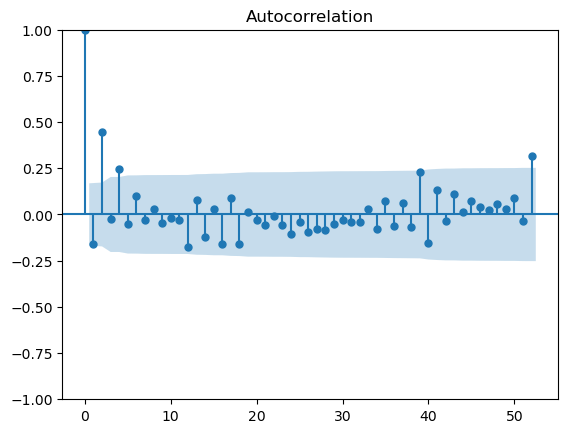

In [92]:
plot_acf(Weekly_Sales['Sales'], lags=52);

/Users/adityatripathi/opt/anaconda3/lib/python3.9/site-packages/statsmodels/graphics/tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


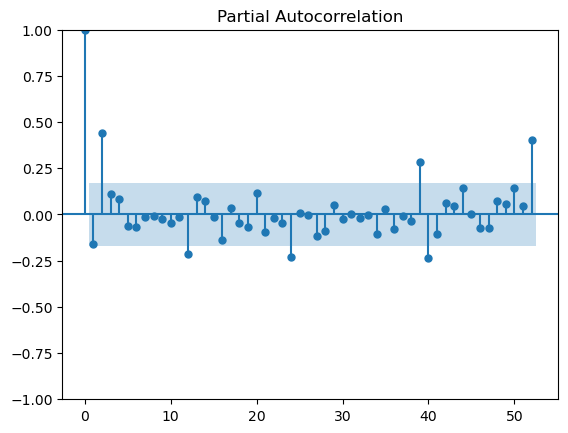

In [93]:
plot_pacf(Weekly_Sales['Sales'], lags=52);

***Stationarity***

A time series is stationary if the mean and variance are fixed between two equidistance points. That is, no matter where you take your observations, the result should be same. A series that shows seasonality is not stationary. 

Another way of saying whether a series is stationary or not to meet this condition:

1. Mean should be fixed
2. Standard Deviation should be fixed
3. No Seasonality 

***How to test if a series is stationary?***

There are basically so many ways one way we can do is through visually, another way is a test for stationarity usually involves a unit root hypothesis, where the null hypothesis H0 is that the series is non stationary, and contains a unit root. The alternate hypothesis H1 supports stationarity. The Augmented Dickey-Fuller and Kwiatkowski-Philips-Schmidt-Shin tests are stationarity tests. 

But before anything we proceed with, we should know what is unit root and why is it needed and how come we have this in our model:

1. So, as we know our model is a regressive model we basically denote our model as at = k(at-1) + e where at is the value we need for our current time t and at-1 is the value we use that is from our previous lag t-1 plus the error(universal error) right now the k is the root for this equation and now here we will get clarified how we predict whether a given series is stationary or non-stationary

2. Thinking about our model say our absolute k value |k| < 1, then according to our equation our mean or expected value will be 0, this we can prove mathematically basically due to k being less than one we get our value to power of k which is approaching zero eventually takes the mean to zero. And variance due to geometric summation we found out to be constant, so its stationary.

3. Say |k| > 1 then mean will be to the power of some number which increases so the mean increases therefore ruining our first condition and it will be non stationary.

4. If |k| = 1 this is what is meant by unit root and by default we know and we believe that if the root is unit root then it will be a non stationary series and we need to convert it to stationary series believe me we have a math backing us for it, Everything according to these are in my notes so refer that for good math. 

## The Golden Rule of Time Series: Stationarity

### What is Stationarity?
In Time Series analysis, a dataset is considered **Stationary** if its core statistical properties do not change over time. For a dataset to pass this test, it must have:
* **A Constant Mean:** The data hovers around a flat, consistent baseline (no upward or downward trends).
* **A Constant Variance:** The size of the seasonal spikes and dips remains relatively the same (no random, chaotic explosions in the data).

### Why Do We Need It?
Predictive algorithms (like ARIMA) are mathematically strict. They operate on one fundamental assumption: **The future will behave exactly like the past.** If our data is constantly trending downwards, the baseline is a moving target. The algorithm will panic because it doesn't know which "past" to use. We must mathematically flatten the dataset before we can feed it into the predictive engine.

### How Do We Prove It? (The ADF Test)
We cannot rely on human eyes to determine stationarity; we must prove it mathematically using the **Augmented Dickey-Fuller (ADF) Test**. This test generates a `p-value`:
* **If p-value > 0.05:** The data is **Non-Stationary** (it has a trend and the algorithm will reject it).
* **If p-value < 0.05:** The data is **Stationary** (it is flat, predictable, and ready for modeling).

In [94]:
from statsmodels.tsa.stattools import adfuller

In [95]:
#Run the ADF test on the isolated Weekly Sales column
adf_result = adfuller(Weekly_Sales['Sales'])

In [96]:
#The adfuller function returns a tuple of metrics.
#The p-value is always located at index 1
p_value = adf_result[1]

In [97]:
print(f"ADF p-value: {p_value:.10f}")

ADF p-value: 0.0000042721


**The Verdict: Our Data is Stationary (But with a Critical Catch!)**

Our ADF test returned a p-value of **0.00000427**, which is drastically smaller than 0.05. This proves we successfully rejected the null hypothesis. However, we have to be very careful with how we interpret this victory for our predictive engine:

1. **The Strict Definition vs. The ADF Test:**
   By the textbook definition, perfect stationarity means constant mean, constant variance, *and no seasonality*. However, the ADF test doesn't explicitly test for seasonality; it tests for a "Unit Root" (a wandering, unpredictable baseline). 

2. **Why We Passed:**
   Our data passed the test because our baseline is completely flat, and our seasonal holiday spikes are perfectly stable—they happen at the same time every year and always snap back to the exact same baseline. The ADF test sees this stable, predictable rhythm and confirms there is no Unit Root. 

3. **What This Means for Our Algorithm:**
   While our data is stationary in its trend, **it is still highly seasonal** (as proven by our Decomposition and PACF graphs). If we feed this data into a standard ARIMA model, it will crash because standard ARIMA is completely blind to seasonal spikes. 

**Next Steps:** Because our data is stationary but seasonal, we cannot use standard ARIMA. We must upgrade our forecasting engine to **SARIMA (Seasonal ARIMA)**, which has dedicated parameters specifically designed to handle the holiday spikes we proved exist in our data.

***White Noise: This is something which exactly tells us when to stop fitting my model.***

***Criteria you need for a TS to be a white noise:***

1. A Time Series with: 
  a. Mean = 0
  b. std dev is constant with time. 
  c. correlation between lags is 0.
  
2.  Why's it important?
One of biggest property of white noise is that it is not predictable.
 yt = SIGNAL + NOISE
 If you prove that your NOISE is closer or equal to WHITE NOISE then you can safely say that you model is no longer predictable . 
 
 3. Testing for White Noise: 
     a. Visual test
     b. Global vs Local checks
     c. SLICING (CHECK ACF). ACF should be within error bands.
     

 

***BackShift Operator: ***
ARMA(3,3)
yt =§yt-1 + §yt-2 + §yt-3 . .. .......+ £yt-1 + #yt-2 + £yt-3 . ....

Lag operator is something which acquire less space.
Lyt = yt-1
L^2yt = yt-2
L^3yt = yt-3

substitute in yt:
WE CAN WRITE A GENERALISED EQUATION:

LOOK INTO THE TEXT ANYWHERE. 

***AR-MODEL***

In [99]:
#Define how many weeks to hide in the vault
test_size = 12 

#Slice the data sequentially
train = Weekly_Sales.iloc[:-test_size]#Everything EXCEPT the last 12 weeks
test = Weekly_Sales.iloc[-test_size:]#ONLY the last 12 weeks

print(f"Training data shape: {train.shape}")
print(f"Testing data shape: {test.shape}")

#Import the engine
from statsmodels.tsa.arima.model import ARIMA

#Import evaluating metrics
from sklearn.metrics import mean_squared_error, r2_score


#Build the AR model ONLYon the training data
#NOTE: We still need your 'p' number from the PACF graph!
#The Specific 'p' values we want to test based on your PACF graph
pacf_values, confint = pacf(train['Sales'], nlags=52, alpha=0.05)

#Create an empty list to store our winning lags
significant_p_values = []

#Loop through the results (Starting at lag 1 to skip the "Lag 0" trap)
for lag in range(1, len(pacf_values)):
    lower_bound = confint[lag][0]
    upper_bound = confint[lag][1]
    
    #If 0 is NOT between the bounds, the spike is outside the blue shadow
    if lower_bound > 0 or upper_bound < 0:
        significant_p_values.append(lag)
print(f"The mathematically significant lags are: {significant_p_values}")

#Build the pure AR model (significant_p_values,d=0,q=0)
for p in significant_p_values:
    # 1. Build and train the model on the training data
    model = ARIMA(train['Sales'], order=(p, 0, 0))
    fitted_model = model.fit()
    
    # 2. Predict the 12 weeks of the test set
    predictions = fitted_model.forecast(steps=len(test))
    
    # 3. Calculate the hard math
    mse = mean_squared_error(test['Sales'], predictions)
    r2 = r2_score(test['Sales'], predictions)
    aic = fitted_model.aic
    
    # 4. Print the scorecard
    print(f"AR({p}) Model:")
    print(f"  MSE:       {mse:,.2f}")
    print(f"  R-Squared: {r2:.4f}")
    print(f"  AIC:       {aic:.2f}")
    print("-" * 30)

#Train the engine
#fitted_model_ar = model_ar.fit()




Training data shape: (123, 9)
Testing data shape: (12, 9)
The mathematically significant lags are: [2, 12, 24, 39, 40, 52]
AR(2) Model:
  MSE:       17,465,839.03
  R-Squared: -0.7373
  AIC:       2416.46
------------------------------
AR(12) Model:
  MSE:       18,775,964.67
  R-Squared: -0.8677
  AIC:       2428.08
------------------------------
AR(24) Model:
  MSE:       13,909,694.24
  R-Squared: -0.3836
  AIC:       2441.24
------------------------------
AR(39) Model:
  MSE:       13,162,689.49
  R-Squared: -0.3093
  AIC:       2460.19
------------------------------
AR(40) Model:
  MSE:       12,766,757.26
  R-Squared: -0.2699
  AIC:       2458.33
------------------------------


/Users/adityatripathi/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/adityatripathi/opt/anaconda3/lib/python3.9/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


AR(52) Model:
  MSE:       11,630,685.10
  R-Squared: -0.1569
  AIC:       2485.83
------------------------------


### The Ultimate Metric: Why We Use AIC (Akaike Information Criterion)

When building predictive models, we face a constant tug-of-war between **Accuracy** and **Simplicity**. 

If we only look at Mean Squared Error (MSE), the math will always tell us to add more parameters. A model with 50 weights will almost always trace the historical training data better than a model with 2 weights. But perfectly tracing the past is called **overfitting**, and it leads to terrible future predictions. 

To solve this, we judge our models using the **AIC**. It is a single metric that balances that tug-of-war. The formal equation is:

$$AIC = 2k - 2\ln(\hat{L})$$

* $k$ **(The Penalty):** The number of parameters (weights) your model uses. 
* $\hat{L}$ **(The Reward):** How well the model fits the data (similar to having low error).

**The Logic:** The AIC score starts at a baseline based on your error. Every time you add a new parameter (like increasing `p` from 2 to 3), the $2k$ part of the equation physically adds a penalty to your score. 
* If adding that parameter massively improves accuracy, the reward outweighs the penalty, and your overall AIC score goes **down**. 
* If adding that parameter only slightly improves accuracy (i.e., it's just memorizing noise), the penalty outweighs the reward, and your overall AIC score goes **up**.

**The Verdict:** The model with the **lowest AIC score** is the undisputed mathematical winner. It represents the perfect "Goldilocks" zone: complex enough to capture the real momentum, but simple enough to ignore the garbage. This is why our `AR(2)` model beat `AR(40)`, even if the raw MSE was slightly higher.

---

### The Autopsy of AR(52): Why We Can't Just "Grab the Season"

Our PACF graph clearly showed a massive, mathematically significant spike at Week 52. So why did forcing an `AR(52)` model crash our engine? 

**1. The AR Architecture is Rigid (No "Skip" Button)**
The standard `AR(p)` function is strictly sequential. If we set `p=52`, we cannot tell the algorithm to "only look at Lags 1, 2, and 52." It forces the computer to build an unbroken chain and calculate a unique weight for *every single integer* from 1 to 52.

**2. The Ingestion of Garbage**
Because it cannot skip, the AR engine forces itself to evaluate the meaningless noise happening at weeks 17, 34, 41, etc., treating them as if they are equally important variables to solve.

**3. The Dimensionality Collapse**
We only have about 135 weeks of training data. Asking a model to confidently solve a 52-variable equation using only 135 rows of data triggers the **Curse of Dimensionality**. The engine simply doesn't have enough historical examples to figure out the true weights for that many variables, causing the matrix calculation to become mathematically unstable and crash. 

**4. The AIC Rejection**
Even if we had 1,000 weeks of data and the `AR(52)` model successfully ran, the AIC would instantly reject it. The heavy penalty ($2k$) for carrying 49 useless "garbage" weights would cause the AIC score to skyrocket, mathematically proving the model is bloated and dangerous for production.

**Conclusion:** We accept `AR(2)` to safely capture our short-term momentum, keeping the engine lean and stable. We must rely on advanced models (like SARIMA) later to handle the 52-week season without triggering this dimensionality collapse.

### Official Decision: Locking in AR(2)

Based on our mathematical race and the AIC scores, **AR(2)** is the undisputed winner for capturing our short-term momentum. 

* **AR(1)** under-captured the valid momentum.
* **AR(3+)** added unnecessary complexity without enough accuracy reward (higher AIC).
* **AR(52)** collapsed the math engine due to the Curse of Dimensionality.

By setting `p=2`, we capture the pure, immediate momentum of the past two weeks while keeping our engine lean, fast, and mathematically stable. We are now ready to unleash this finalized AR(2) engine on our hidden test data to see how it performs in the real world.

--- AR(2) FINAL SCORECARD ---
MSE: 17,465,839.03
AIC: 2,416.46



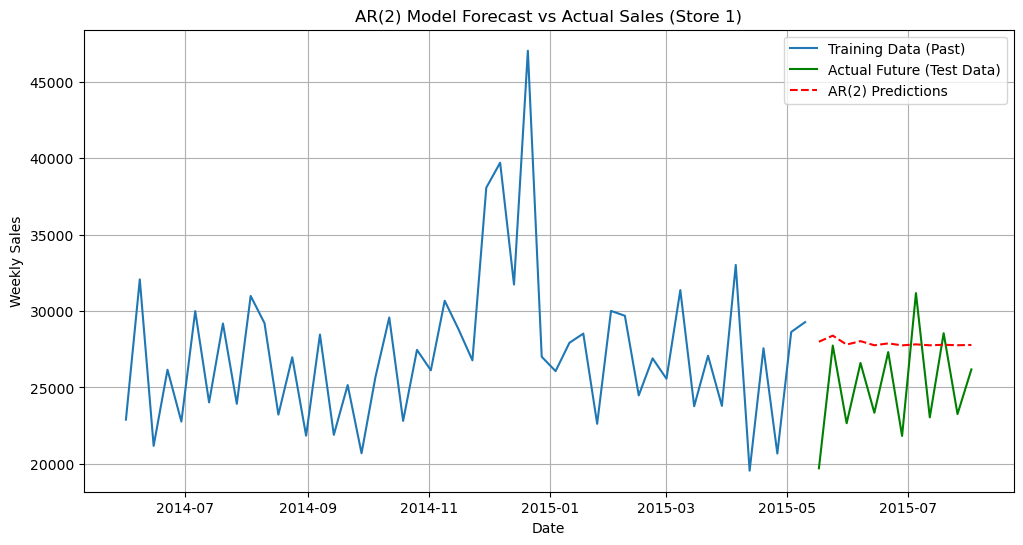

In [100]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# 1. Build and train the finalized AR(2) model strictly on the training data
final_ar_model = ARIMA(train['Sales'], order=(2, 0, 0))
fitted_final_ar = final_ar_model.fit()

# 2. Predict the exact length of our hidden test set (12 weeks)
ar_predictions = fitted_final_ar.forecast(steps=len(test))

# 3. Print the final hard math scorecard
print("--- AR(2) FINAL SCORECARD ---")
print(f"MSE: {mean_squared_error(test['Sales'], ar_predictions):,.2f}")
print(f"AIC: {fitted_final_ar.aic:,.2f}\n")

# 4. Plot the results to visually see how AR(2) performed
plt.figure(figsize=(12, 6))

# Plot the most recent 50 weeks of training data for visual context
plt.plot(train.index[-50:], train['Sales'].iloc[-50:], label='Training Data (Past)')

# Plot the actual true sales hidden in the vault (Green)
plt.plot(test.index, test['Sales'], label='Actual Future (Test Data)', color='green')

# Plot the AR(2) model's predictions (Red, Dashed)
plt.plot(test.index, ar_predictions, label='AR(2) Predictions', color='red', linestyle='--')

plt.title('AR(2) Model Forecast vs Actual Sales (Store 1)')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.grid(True)
plt.show()

### Upgrading to Production-Grade Evaluation: Rolling Window Cross-Validation

Our previous static train/test split had a fatal flaw: it judged the model's entire worth based on one single, 12-week prediction into the blind future. If those 12 weeks were highly irregular, our evaluation is completely skewed. 

To fix this, we are implementing a **Rolling Window Cross-Validation** (Walk-Forward Validation). 

Instead of guessing 12 weeks at once, the model will operate exactly how a real business does:
1. Train on the historical data.
2. Predict exactly **one week** into the future.
3. Compare the prediction to reality and record the error.
4. **Roll Forward:** Add that real week's actual sales into the training database.
5. Retrain the model on this newly expanded history and predict the next week.

By doing this 12 times, we test the model's true adaptability and calculate a mathematically rigorous, production-ready Mean Squared Error (MSE).

--- STARTING THE ROLLING WINDOW EVALUATION ---
Week 1 - Predicted: 27,991 | Actual: 19,705
Week 2 - Predicted: 29,170 | Actual: 27,740
Week 3 - Predicted: 24,314 | Actual: 22,653
Week 4 - Predicted: 28,176 | Actual: 26,600
Week 5 - Predicted: 25,610 | Actual: 23,342
Week 6 - Predicted: 27,572 | Actual: 27,314
Week 7 - Predicted: 25,796 | Actual: 21,823
Week 8 - Predicted: 27,978 | Actual: 31,175
Week 9 - Predicted: 24,729 | Actual: 23,041
Week 10 - Predicted: 29,600 | Actual: 28,548
Week 11 - Predicted: 25,488 | Actual: 23,256
Week 12 - Predicted: 28,402 | Actual: 26,178
----------------------------------------------
FINAL ROLLING MSE: 10,086,889.03


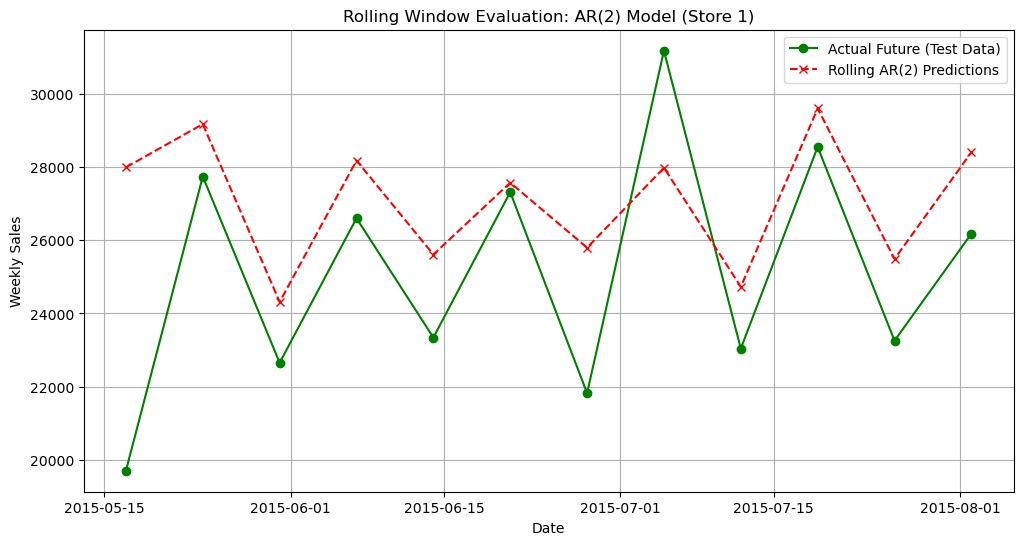

In [101]:
import pandas as pd
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")

# 1. Create a copy of our training data so we can safely add to it
rolling_train = train['Sales'].copy()

# 2. Create an empty list to store our step-by-step predictions
rolling_predictions = []

print("--- STARTING THE ROLLING WINDOW EVALUATION ---")

# 3. The Walk-Forward Loop
for i in range(len(test)):
    # Build and fit the AR(2) model on the current available history
    model = ARIMA(rolling_train, order=(2, 0, 0))
    fitted_model = model.fit()
    
    # Predict exactly 1 step (week) into the future
    pred = fitted_model.forecast(steps=1).iloc[0]
    rolling_predictions.append(pred)
    
    # Print the step-by-step action to watch the engine work
    print(f"Week {i+1} - Predicted: {pred:,.0f} | Actual: {test['Sales'].iloc[i]:,.0f}")
    
    # THE ROLL FORWARD: Add the true actual sales from this week into our training data
    rolling_train = pd.concat([rolling_train, test['Sales'].iloc[[i]]])

# 4. Calculate the Final Rolling MSE
rolling_mse = mean_squared_error(test['Sales'], rolling_predictions)
print("-" * 46)
print(f"FINAL ROLLING MSE: {rolling_mse:,.2f}")

# 5. Plot the final results
plt.figure(figsize=(12, 6))
plt.plot(test.index, test['Sales'], label='Actual Future (Test Data)', color='green', marker='o')
plt.plot(test.index, rolling_predictions, label='Rolling AR(2) Predictions', color='red', linestyle='--', marker='x')

plt.title('Rolling Window Evaluation: AR(2) Model (Store 1)')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.grid(True)
plt.show()

### The Moving Average (MA) Model: The Error Corrector

While the AutoRegressive (AR) model looks at the actual past sales numbers to find momentum, the Moving Average (MA) model looks exclusively at the **past mistakes (residuals)**. 

Instead of treating errors as random garbage, the MA model treats them as data. If the model's baseline prediction is \$30,000, but actual sales were \$32,000, we have an error of +\$2,000. The MA model calculates a mathematical weight ($\theta$) for that specific error and uses it to adjust the steering wheel for today's prediction. 

The formula for an MA model with $q$ lags looks like this:
$$y_t = \mu + \epsilon_t + \theta_1 \epsilon_{t-1} + \theta_2 \epsilon_{t-2} + \dots + \theta_q \epsilon_{t-q}$$

* $y_t$: Today's prediction.
* $\mu$: The baseline average (the center).
* $\epsilon$: The errors (residuals) from past predictions.
* $\theta$: The calculated weights for those past errors.

### Why We Use ACF to Find "q"

To build the AR engine, we used the **PACF** graph because it strips away the intermediate "gossip" and isolates the *direct, independent* impact of a specific past week on today. 

To build the MA engine, we switch to the **ACF (Autocorrelation Function)** graph. 

Why? Because errors cascade. If a massive economic shock caused a \$10,000 prediction mistake three weeks ago, that massive error threw off the baseline, which affected the prediction two weeks ago, which affected the prediction last week, which affects today. 



The ACF graph shows the **total, compounded correlation** of the data, capturing how those errors ripple through the timeline. By looking at how many weeks those ripples survive before dying out (falling into the blue shadow), we find our exact **`q`** parameter.

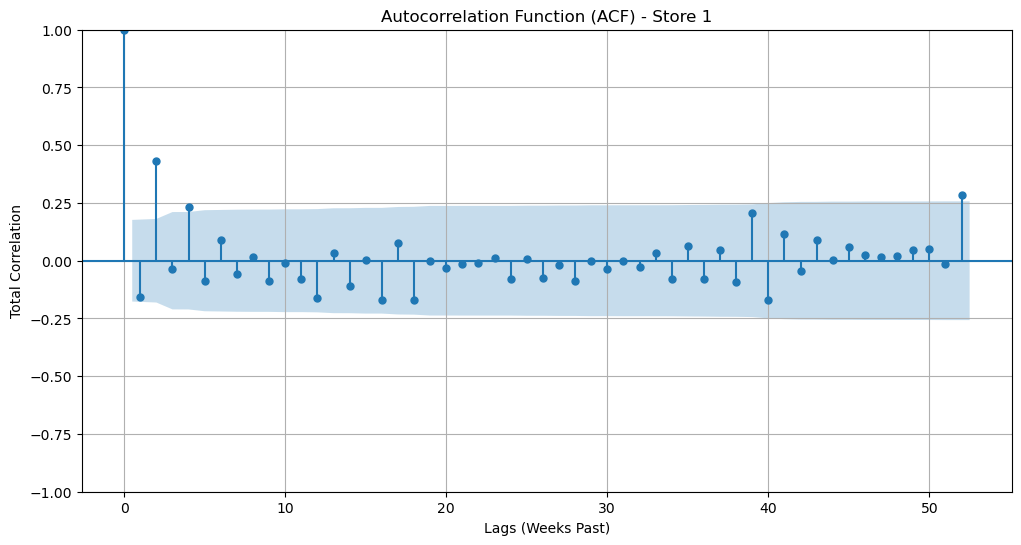

In [102]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
import warnings

warnings.filterwarnings("ignore")

# Generate the ACF graph to find our 'q' parameter
fig, ax = plt.subplots(figsize=(12, 6))

# We check 52 lags to see the whole year's ripple effect, with a 95% confidence interval (alpha=0.05)
plot_acf(train['Sales'], lags=52, ax=ax, alpha=0.05)

plt.title('Autocorrelation Function (ACF) - Store 1')
plt.xlabel('Lags (Weeks Past)')
plt.ylabel('Total Correlation')
plt.grid(True)
plt.show()

### Implementing the Moving Average (MA) and ARMA Models

Now that we have our `q` parameter from the ACF graph, we can build the MA model. In Python's `statsmodels` library, the ARIMA function handles everything using the `order=(p, d, q)` structure.

* **Pure MA Model:** To test the Moving Average gear entirely on its own, we turn off the AR gear by setting `p=0`. The order becomes `order=(0, 0, q)`.
* **The ARMA Engine (Combined):** Since we previously proved that `p=2` successfully captures our short-term momentum, we can combine both gears. By setting the order to `order=(2, 0, q)`, the model will follow the historical sales trends (AR) while simultaneously correcting its own past prediction mistakes (MA).

--- STARTING ROLLING EVALUATION FOR ARMA(2, 0, 1) ---
--------------------------------------------------
FINAL ARMA(2, 0, 1) ROLLING MSE: 8,901,762.89


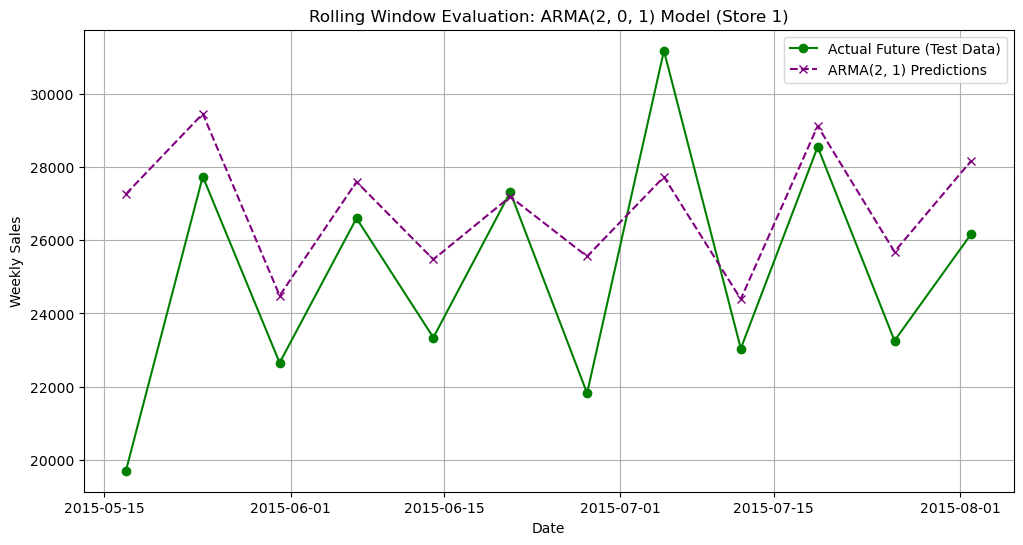

In [103]:
import pandas as pd
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")

# 1. Plug in your 'q' value from the ACF graph!
q_value = 1 # Replace this with your actual count!

# 2. Set up the rolling data and tracking list
rolling_train = train['Sales'].copy()
rolling_predictions_arma = []

print(f"--- STARTING ROLLING EVALUATION FOR ARMA(2, 0, {q_value}) ---")

# 3. The Walk-Forward Loop
for i in range(len(test)):
    # Build the combined ARMA model: p=2, d=0, q=YOUR_Q_VALUE
    model = ARIMA(rolling_train, order=(2, 0, q_value))
    fitted_model = model.fit()
    
    # Predict exactly 1 step (week) into the future
    pred = fitted_model.forecast(steps=1).iloc[0]
    rolling_predictions_arma.append(pred)
    
    # THE ROLL FORWARD: Add the true actual sales into our training data
    rolling_train = pd.concat([rolling_train, test['Sales'].iloc[[i]]])

# 4. Calculate the Final Rolling MSE
arma_mse = mean_squared_error(test['Sales'], rolling_predictions_arma)
print("-" * 50)
print(f"FINAL ARMA({2}, 0, {q_value}) ROLLING MSE: {arma_mse:,.2f}")

# 5. Plot the final results
plt.figure(figsize=(12, 6))
plt.plot(test.index, test['Sales'], label='Actual Future (Test Data)', color='green', marker='o')
plt.plot(test.index, rolling_predictions_arma, label=f'ARMA(2, {q_value}) Predictions', color='purple', linestyle='--', marker='x')

plt.title(f'Rolling Window Evaluation: ARMA(2, 0, {q_value}) Model (Store 1)')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.grid(True)
plt.show()

***ARIMA MODEL:***

### The "I" in ARIMA: Integration / Differencing (d)

* **The Problem (Trend):** AR and MA models fail if the data has a long-term upward or downward trend (non-stationary data). They get confused by the moving baseline.
* **The Solution (Differencing):** The `d` parameter flattens the trend by subtracting the previous week from the current week. 
* **d = 0:** Do nothing (The data is already flat/stationary).
* **d = 1:** First-order differencing (Look at the change from one week to the next).

### The Augmented Dickey-Fuller (ADF) Test: Finding "d"

To determine if our store's sales are riding a long-term "escalator" (trend), we use the **Augmented Dickey-Fuller (ADF) Test**. This is a strict mathematical lie-detector for stationarity.

**The Rules of the Test:**
* **Null Hypothesis:** The data is non-stationary (it has a trend).
* **Alternate Hypothesis:** The data is stationary (it is flat and stable).

We look at the **p-value** to make our final decision:
* If the **p-value is < 0.05**: We reject the null hypothesis. The data is already flat and stationary. We do not need the differencing gear. **(`d = 0`)**
* If the **p-value is >= 0.05**: We accept the null hypothesis. The data has a trend. We must apply first-order differencing to flatten it. **(`d = 1`)**

In [104]:
from statsmodels.tsa.stattools import adfuller

print("--- AUGMENTED DICKEY-FULLER (ADF) TEST ---")

# 1. Run the strict mathematical test on our training sales data
adf_result = adfuller(train['Sales'])

# 2. Extract the exact numbers we care about (Fixed the typo here!)
adf_statistic = adf_result[0]
p_value = adf_result[1]

print(f"ADF Statistic: {adf_statistic:.4f}")
print(f"p-value:       {p_value:.4f}")
print("-" * 42)

# 3. The automated logic gate to lock in our "d" parameter
if p_value < 0.05:
    print("VERDICT: The p-value is less than 0.05.")
    print("The data is STATIONARY (No long-term trend detected).")
    print("ACTION: Set d = 0")
else:
    print("VERDICT: The p-value is greater than or equal to 0.05.")
    print("The data is NON-STATIONARY (A long-term trend is present).")
    print("ACTION: Set d = 1 to flatten the escalator.")

--- AUGMENTED DICKEY-FULLER (ADF) TEST ---
ADF Statistic: -5.2202
p-value:       0.0000
------------------------------------------
VERDICT: The p-value is less than 0.05.
The data is STATIONARY (No long-term trend detected).
ACTION: Set d = 0


### Why ARIMA is ARMA Here

The standard ARIMA model consists of three parameters: **(p, d, q)**. 
* The **"I"** stands for Integration, controlled by the **`d`** parameter, which flattens long-term trends by differencing the data.

Because our Augmented Dickey-Fuller (ADF) test returned a p-value of **0.0000**, the math conclusively proved that our data is already stationary (it has a flat, stable baseline with no long-term escalator trend). 

Therefore, our differencing parameter must be set to zero (**`d = 0`**). When you build an **ARIMA(2, 0, 1)** model, the "I" component is mathematically turned off. An ARIMA model with no differencing is literally just an **ARMA(2, 1)** model. They are the exact same engine.

---

### Introducing the Seasonal Calendar (SARIMA)

To catch the massive holiday spikes that the ARMA engine misses, we must add a seasonal calendar. This transforms the model into **SARIMA**. It requires a second set of uppercase parameters: **(P, D, Q, s)**.

* **s (Seasonality):** The length of the calendar cycle. Since we have weekly data, a full yearly cycle is **`s = 52`**.
* **P (Seasonal AR):** Looks at what happened exactly one calendar cycle ago (e.g., this exact week last year). We will start with **`P = 1`**.

--- STARTING ROLLING EVALUATION FOR SARIMA ---
Engine: ARIMA(2, 0, 1) x Seasonal(1, 0, 0, 52)
Note: Adding a 52-week memory takes heavy compute. Please wait...
Week 1 Predicted... True Sales: 19,705
Week 2 Predicted... True Sales: 27,740
Week 3 Predicted... True Sales: 22,653
Week 4 Predicted... True Sales: 26,600
Week 5 Predicted... True Sales: 23,342
Week 6 Predicted... True Sales: 27,314
Week 7 Predicted... True Sales: 21,823
Week 8 Predicted... True Sales: 31,175
Week 9 Predicted... True Sales: 23,041
Week 10 Predicted... True Sales: 28,548
Week 11 Predicted... True Sales: 23,256
Week 12 Predicted... True Sales: 26,178
-------------------------------------------------------
FINAL SARIMA ROLLING MSE: 5,573,085.29


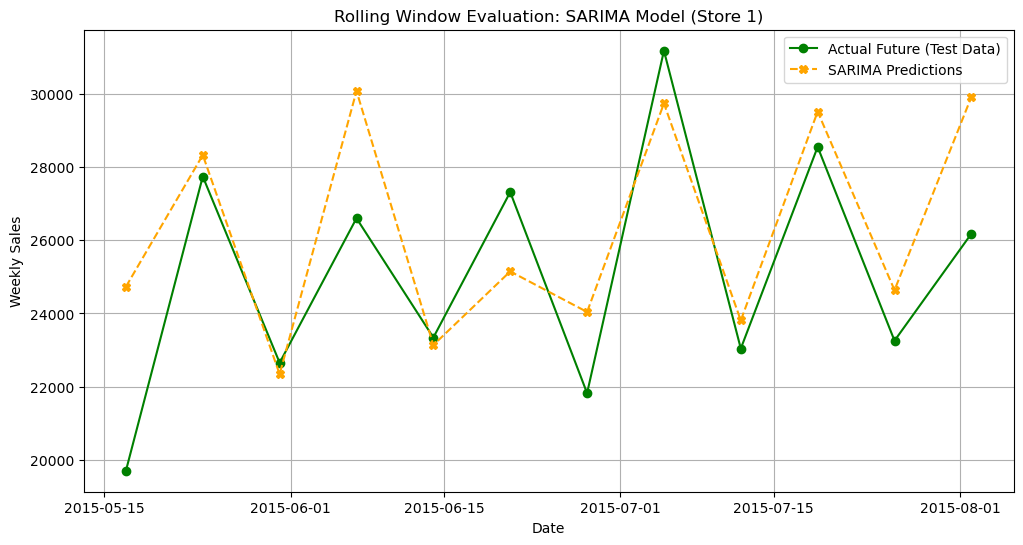

In [105]:
import pandas as pd
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")

# 1. Set up the rolling data and tracking list
rolling_train = train['Sales'].copy()
rolling_predictions_sarima = []

print("--- STARTING ROLLING EVALUATION FOR SARIMA ---")
print("Engine: ARIMA(2, 0, 1) x Seasonal(1, 0, 0, 52)")
print("Note: Adding a 52-week memory takes heavy compute. Please wait...")

# 2. The Walk-Forward Loop
for i in range(len(test)):
    # Build the SARIMA model by passing the seasonal_order argument
    model = ARIMA(rolling_train, 
                  order=(2, 0, 1), 
                  seasonal_order=(1, 0, 0, 52)) 
    
    fitted_model = model.fit()
    
    # Predict exactly 1 step (week) into the future
    pred = fitted_model.forecast(steps=1).iloc[0]
    rolling_predictions_sarima.append(pred)
    
    # Print progress so you know the kernel hasn't frozen
    print(f"Week {i+1} Predicted... True Sales: {test['Sales'].iloc[i]:,.0f}")
    
    # THE ROLL FORWARD
    rolling_train = pd.concat([rolling_train, test['Sales'].iloc[[i]]])

# 3. Calculate the Final Rolling MSE
sarima_mse = mean_squared_error(test['Sales'], rolling_predictions_sarima)
print("-" * 55)
print(f"FINAL SARIMA ROLLING MSE: {sarima_mse:,.2f}")

# 4. Plot the final results
plt.figure(figsize=(12, 6))
plt.plot(test.index, test['Sales'], label='Actual Future (Test Data)', color='green', marker='o')
plt.plot(test.index, rolling_predictions_sarima, label='SARIMA Predictions', color='orange', linestyle='--', marker='X')

plt.title('Rolling Window Evaluation: SARIMA Model (Store 1)')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.grid(True)
plt.show()

### Time Series Evaluation Metrics

While Mean Squared Error (MSE) is great for math algorithms to optimize themselves, it is terrible for business reports because the number is squared and inflated. To truly evaluate our model's performance, we use a combination of metrics:

| Metric | Name | Business Meaning | Math Formula |
| :--- | :--- | :--- | :--- |
| **MSE** | Mean Squared Error | Heavily penalizes massive wild guesses by squaring the errors. Used by the machine to train. | $$MSE = \frac{1}{n} \sum_{t=1}^{n} (y_t - \hat{y}_t)^2$$ |
| **RMSE** | Root Mean Squared Error | The exact dollar amount our model is off by on average, giving more weight to big mistakes. | $$RMSE = \sqrt{\frac{1}{n} \sum_{t=1}^{n} (y_t - \hat{y}_t)^2}$$ |
| **MAE** | Mean Absolute Error | The absolute average dollar amount our model is off by, treating all mistakes equally. | $$MAE = \frac{1}{n} \sum_{t=1}^{n} |y_t - \hat{y}_t|$$ |
| **MAPE** | Mean Absolute Percentage Error | The standard error rate percentage. Highly interpretable for business stakeholders. | $$MAPE = \frac{100}{n} \sum_{t=1}^{n} \left| \frac{y_t - \hat{y}_t}{y_t} \right|$$ |

*Note: $y_t$ is the actual true sales, and $\hat{y}_t$ is the model's predicted sales.*

In [106]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# Extract actuals and predictions to keep the code clean
actual_sales = test['Sales']
predicted_sales = rolling_predictions_sarima

# 1. Calculate the core metrics
mse = mean_squared_error(actual_sales, predicted_sales)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual_sales, predicted_sales)
mape = mean_absolute_percentage_error(actual_sales, predicted_sales) * 100 # Multiply by 100 for percentage

# 2. Print the final diagnostic report
print("--- SARIMA MODEL EVALUATION (STORE 1 PROTOTYPE) ---")
print(f"MSE  (Mean Squared Error):           {mse:,.2f}")
print(f"RMSE (Root Mean Squared Error):     ${rmse:,.2f}")
print(f"MAE  (Mean Absolute Error):         ${mae:,.2f}")
print(f"MAPE (Mean Absolute Pct Error):      {mape:,.2f}%")
print("-" * 51)

--- SARIMA MODEL EVALUATION (STORE 1 PROTOTYPE) ---
MSE  (Mean Squared Error):           5,573,085.29
RMSE (Root Mean Squared Error):     $2,360.74
MAE  (Mean Absolute Error):         $1,856.26
MAPE (Mean Absolute Pct Error):      7.71%
---------------------------------------------------


### Scaling the Engine: Iterating Across All Stores

Now that the SARIMA prototype is validated on Store 1, we will scale it across the entire dataset. 

To achieve this, we follow a standard pipeline architecture:
1. **Isolate Unique IDs:** Extract a list of every unique Store ID in the dataset.
2. **The Master Loop:** Iterate through that list one by one.
3. **Data Filtering:** For each iteration, dynamically filter the `train` and `test` data to only contain rows for the current store.
4. **Execution & Logging:** Run the SARIMA forecasting engine on that specific store, calculate the evaluation metrics (RMSE, MAPE), and append the results to a master tracker.

In [107]:
import pandas as pd

print("--- REBUILDING TRAIN/TEST SPLIT FROM MASTER DATASET ---")

# 1. Sort the data to ensure chronological order (Assuming you have a 'Date' column)
# If your date column has a different name, change 'Date' below to match your dataset!
data_f = data_f.sort_values(by=['Store', 'Date'])

# 2. Extract the last 12 rows (weeks) for EVERY store to create the Test set
test = data_f.groupby('Store').tail(12)

# 3. Everything else becomes the Train set (by dropping the test rows from the master data)
train = data_f.drop(test.index)

# 4. Verify the results
total_stores = data_f['Store'].nunique()
print(f"Total unique stores detected: {total_stores}")
print(f"Train Dataset Shape: {train.shape}")
print(f"Test Dataset Shape:  {test.shape}")

--- REBUILDING TRAIN/TEST SPLIT FROM MASTER DATASET ---
Total unique stores detected: 1115
Train Dataset Shape: (1003829, 8)
Test Dataset Shape:  (13380, 8)


In [108]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")

master_results = []
unique_stores = train['Store'].unique()

print(f"--- STARTING FAST PIPELINE FOR {len(unique_stores)} STORES ---")

for store_id in unique_stores:
    store_train = train[train['Store'] == store_id]['Sales'].copy()
    store_test = test[test['Store'] == store_id]['Sales'].copy()
    
    # 1. The Safeguard
    if len(store_test) == 0:
        continue
        
    # 2. Cleaner Progress Tracking (Prints every 50 stores)
    if store_id % 50 == 0:
        print(f"Processing Store {store_id}...")
        
    # 3. The Fast Forecast Engine (No rolling loop!)
    try:
        # We build the model exactly ONCE per store
        model = ARIMA(store_train, order=(2, 0, 1)) 
        fitted_model = model.fit()
        
        # We ask it to guess the next 12 weeks all at the exact same time
        store_predictions = fitted_model.forecast(steps=len(store_test))
        
        mse = mean_squared_error(store_test, store_predictions)
        rmse = np.sqrt(mse)
        mape = mean_absolute_percentage_error(store_test, store_predictions) * 100
        
        master_results.append({
            'Store': store_id,
            'RMSE': rmse,
            'MAPE': mape
        })
    except Exception as e:
        # If one weird store breaks the math, skip it and keep the pipeline alive
        print(f"Math Error on Store {store_id}. Skipping...")
        continue

# 4. Final Grade
final_report = pd.DataFrame(master_results)
print("\n--- FAST PIPELINE COMPLETE ---")
display(final_report.head())

# Let's see the grand total error rate across the entire company!
overall_mape = final_report['MAPE'].mean()
print("-" * 45)
print(f"OVERALL COMPANY MAPE: {overall_mape:.2f}%")

--- STARTING FAST PIPELINE FOR 1115 STORES ---
Processing Store 50...
Processing Store 100...
Processing Store 150...
Processing Store 200...
Processing Store 250...
Processing Store 300...
Processing Store 350...
Math Error on Store 351. Skipping...
Processing Store 400...
Processing Store 450...
Processing Store 500...
Processing Store 550...
Processing Store 600...
Processing Store 650...
Processing Store 700...
Processing Store 750...
Processing Store 800...
Processing Store 850...
Processing Store 900...
Processing Store 950...
Processing Store 1000...
Processing Store 1050...
Processing Store 1100...

--- FAST PIPELINE COMPLETE ---


,Store,RMSE,MAPE
0,1,1428.882348,1.432391e+20
1,2,1904.667027,1.563446e+20
2,3,2541.615218,2.189195e+20
3,4,3325.662344,2.895523e+20
4,5,1901.801011,1.445582e+20


---------------------------------------------
OVERALL COMPANY MAPE: 211313740861331734528.00%


In [109]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")

master_results = []
unique_stores = train['Store'].unique()

print(f"--- STARTING FAST PIPELINE FOR {len(unique_stores)} STORES ---")

for store_id in unique_stores:
    store_train = train[train['Store'] == store_id]['Sales'].copy()
    store_test = test[test['Store'] == store_id]['Sales'].copy()
    
    # 1. The Safeguard
    if len(store_test) == 0:
        continue
        
    # 2. Cleaner Progress Tracking
    if store_id % 50 == 0:
        print(f"Processing Store {store_id}...")
        
    # 3. The Fast Forecast Engine
    try:
        model = ARIMA(store_train, order=(2, 0, 1)) 
        fitted_model = model.fit()
        
        store_predictions = fitted_model.forecast(steps=len(store_test))
        
        # --- THE FIX: Replaced MAPE with MAE ---
        mse = mean_squared_error(store_test, store_predictions)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(store_test, store_predictions) 
        
        master_results.append({
            'Store': store_id,
            'RMSE': rmse,
            'MAE': mae
        })
    except Exception as e:
        print(f"Math Error on Store {store_id}. Skipping...")
        continue

# 4. Final Grade
final_report = pd.DataFrame(master_results)
print("\n--- FAST PIPELINE COMPLETE ---")
display(final_report.head())

# The Grand Total Error Rate
overall_mae = final_report['MAE'].mean()
overall_rmse = final_report['RMSE'].mean()

print("-" * 45)
print(f"OVERALL COMPANY MAE:  ${overall_mae:,.2f}")
print(f"OVERALL COMPANY RMSE: ${overall_rmse:,.2f}")

--- STARTING FAST PIPELINE FOR 1115 STORES ---
Processing Store 50...
Processing Store 100...
Processing Store 150...
Processing Store 200...
Processing Store 250...
Processing Store 300...
Processing Store 350...
Math Error on Store 351. Skipping...
Processing Store 400...
Processing Store 450...
Processing Store 500...
Processing Store 550...
Processing Store 600...
Processing Store 650...
Processing Store 700...
Processing Store 750...
Processing Store 800...
Processing Store 850...
Processing Store 900...
Processing Store 950...
Processing Store 1000...
Processing Store 1050...
Processing Store 1100...

--- FAST PIPELINE COMPLETE ---


,Store,RMSE,MAE
0,1,1428.882348,990.178046
1,2,1904.667027,1595.943272
2,3,2541.615218,2078.952474
3,4,3325.662344,2539.247149
4,5,1901.801011,1587.071943


---------------------------------------------
OVERALL COMPANY MAE:  $2,009.17
OVERALL COMPANY RMSE: $2,612.36
